In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

plt.style.use("ggplot")

In [18]:
df = pd.read_csv("../dataset/Mall_Customers.csv")


In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [21]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [22]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.shape

(200, 5)

In [25]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

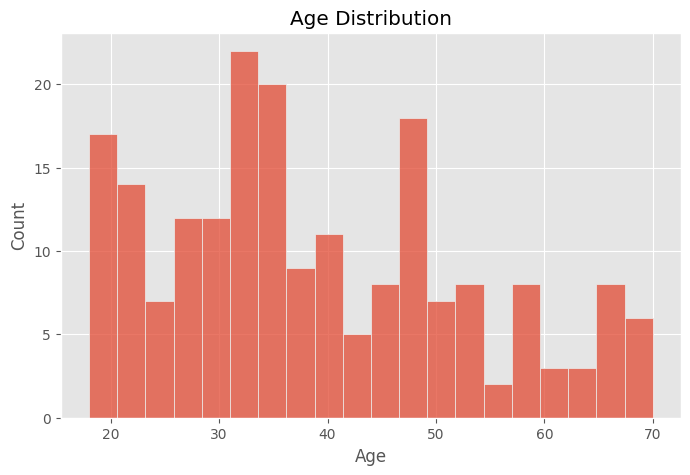

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.savefig("../image/age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

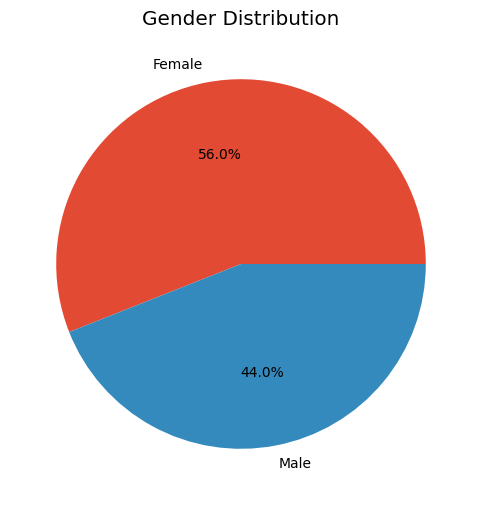

In [27]:
plt.figure(figsize=(6,6))
df['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%'
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.savefig("../image/gender_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

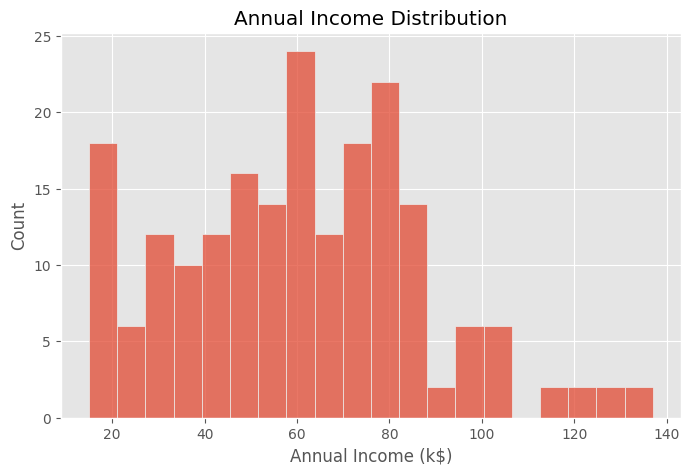

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=20)
plt.title("Annual Income Distribution")
plt.savefig("../image/income_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

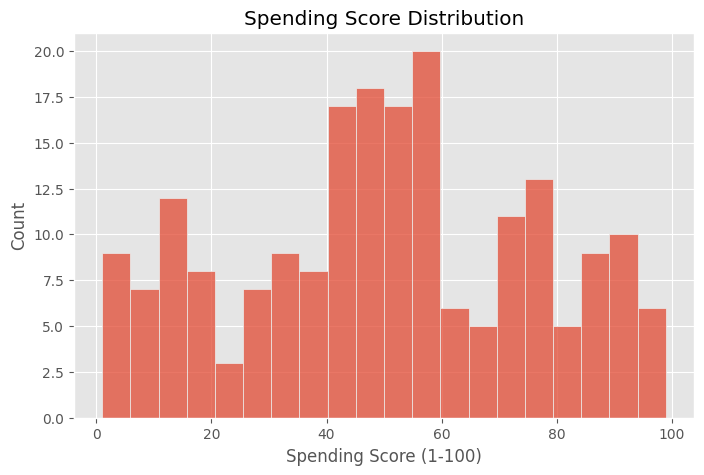

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")
plt.savefig("../image/spending_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

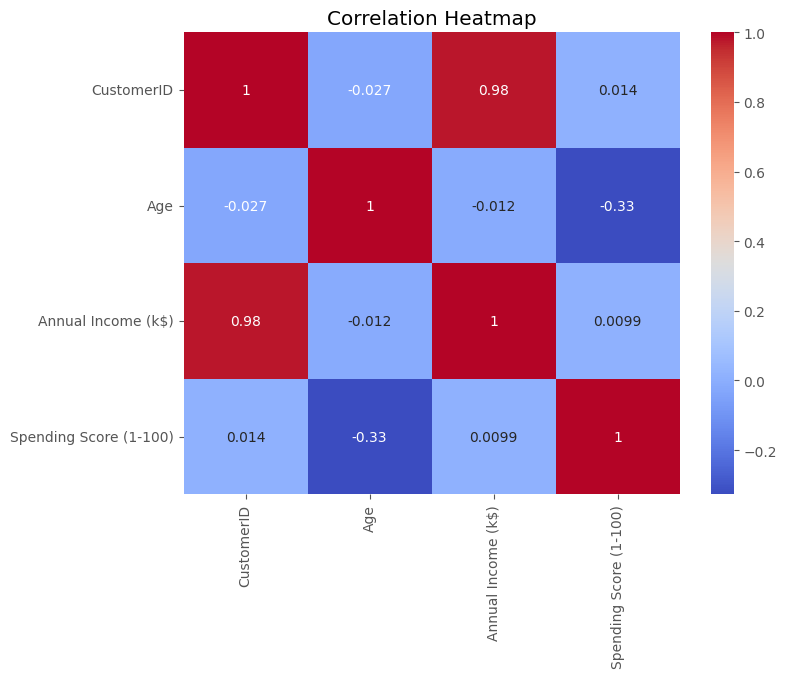

In [30]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("../image/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

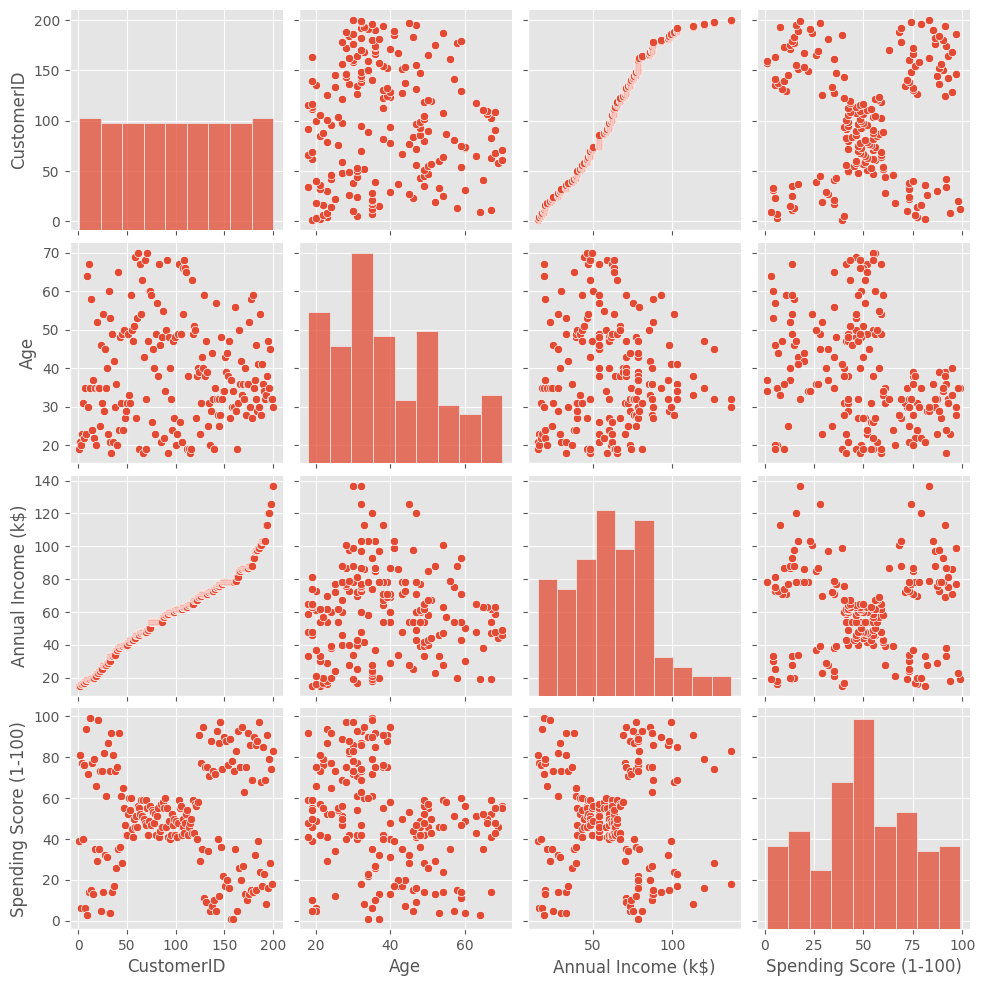

In [31]:
sns.pairplot(df)
plt.savefig("../image/pairplot.png")
plt.show()

In [32]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]


In [33]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

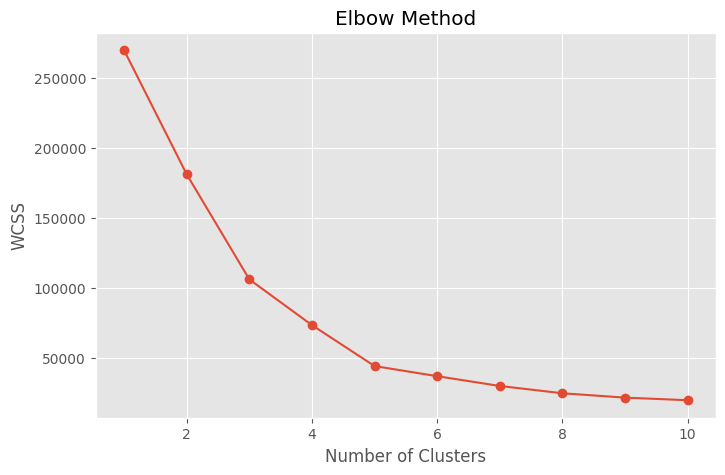

In [34]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.savefig("../image/elbow_method.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

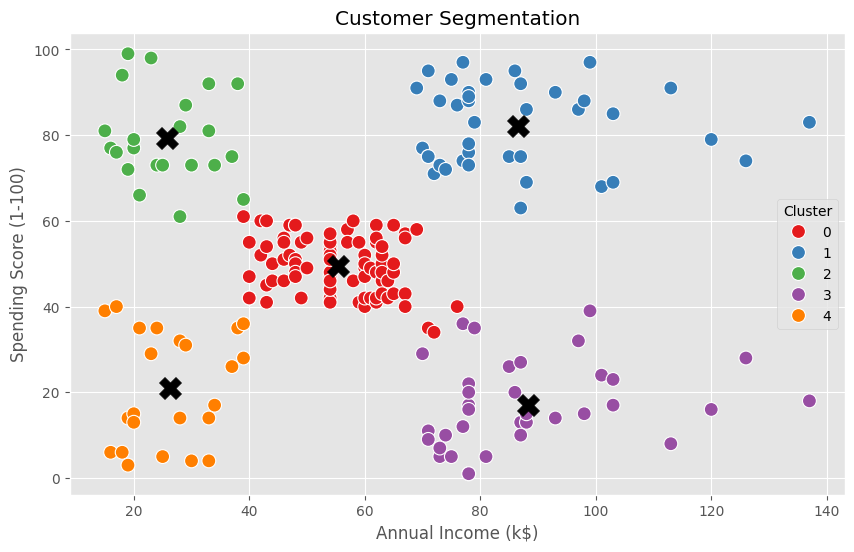

In [36]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    color='black',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("Customer Segmentation")
plt.savefig("../image/customer_segmentation.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

# Conclusion

In this project, customer segmentation was performed using the K-Means clustering algorithm. The analysis grouped customers based on their Annual Income and Spending Score, helping identify different customer segments.

The identified segments can help businesses:
- Understand customer purchasing behavior.
- Design targeted marketing campaigns.
- Improve customer retention.
- Allocate resources more effectively.
- Increase overall sales and customer satisfaction.

This project enhanced my understanding of data preprocessing, exploratory data analysis, data visualization, and unsupervised machine learning using K-Means clustering.